# Experiment 3: ODE Trajectory Embedding

All experiments use **analytic scores** for Gaussian mixtures (no trained model) and the **VP noise schedule**.

Experiments:
1. Trajectory visualization
2. Varying cluster separation
3. Growth rate: new-cluster-per-point (linear) vs single-cluster (log)
4. Effect of sample variance (fixed model, varying data spread)

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve().parent))

from core.model import AnalyticScoreModel, VPNoiseSchedule
from core.trajectory import ode_trajectories, trajectory_embedding, beta_weights
from core.complexity import (
    pairwise_distance, calibrate_bandwidth, gaussian_kernel, complexity, compute_complexity
)

SEED = 42


def make_gmm_means(K, D, delta):
    """Place K cluster means equally spaced on a circle of radius delta."""
    angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
    means = delta * np.column_stack([np.cos(angles), np.sin(angles)])
    if D > 2:
        means = np.hstack([means, np.zeros((K, D - 2))])
    return means


def sample_gmm(means, covs, weights, N, seed=None):
    """Sample N points from a GMM."""
    rng = np.random.default_rng(seed)
    K = len(means)
    labels = rng.choice(K, size=N, p=weights)
    x = np.zeros((N, means.shape[1]))
    for k in range(K):
        mask = labels == k
        x[mask] = rng.multivariate_normal(means[k], covs[k], mask.sum())
    return x, labels


def sample_gmm_roundrobin(means, covs, N, seed=None):
    """Sample N points cycling through clusters deterministically."""
    rng = np.random.default_rng(seed)
    K = len(means)
    D = means.shape[1]
    x = np.zeros((N, D))
    labels = np.zeros(N, dtype=int)
    for i in range(N):
        k = i % K
        labels[i] = k
        x[i] = rng.multivariate_normal(means[k], covs[k])
    return x, labels


# Default setup
ns = VPNoiseSchedule()
L = 20
t_eval = np.linspace(0.01, 0.99, L)

print('Setup complete.')
print(f'VP schedule: beta_min={ns.beta_min}, beta_max={ns.beta_max}')
print(f'Time grid: {L} points in [{t_eval[0]:.2f}, {t_eval[-1]:.2f}]')

Setup complete.
VP schedule: beta_min=0.1, beta_max=20.0
Time grid: 20 points in [0.01, 0.99]


## 1. Trajectory Visualization

Visualize ODE trajectories for a 3-component GMM. Under VP, trajectories should converge toward the origin as $t \to 1$ (the prior $\mathcal{N}(0, I)$).

In [2]:
K_vis, D_vis, delta_vis = 3, 2, 5.0
means_vis = make_gmm_means(K_vis, D_vis, delta_vis)
covs_vis = np.tile(np.eye(D_vis), (K_vis, 1, 1))
weights_vis = np.ones(K_vis) / K_vis
model_vis = AnalyticScoreModel(means_vis, covs_vis, weights_vis, noise_schedule=ns)

# 4 points per cluster
N_vis = 4 * K_vis
x_vis, labels_vis = sample_gmm_roundrobin(means_vis, covs_vis, N_vis, seed=SEED)

# Dense time grid for smooth curves
t_dense = np.linspace(0.01, 0.99, 100)
print(f'Computing {N_vis} trajectories...')
traj_vis = ode_trajectories(x_vis, model_vis, t_dense)
print('Done.')

Computing 12 trajectories...
Done.


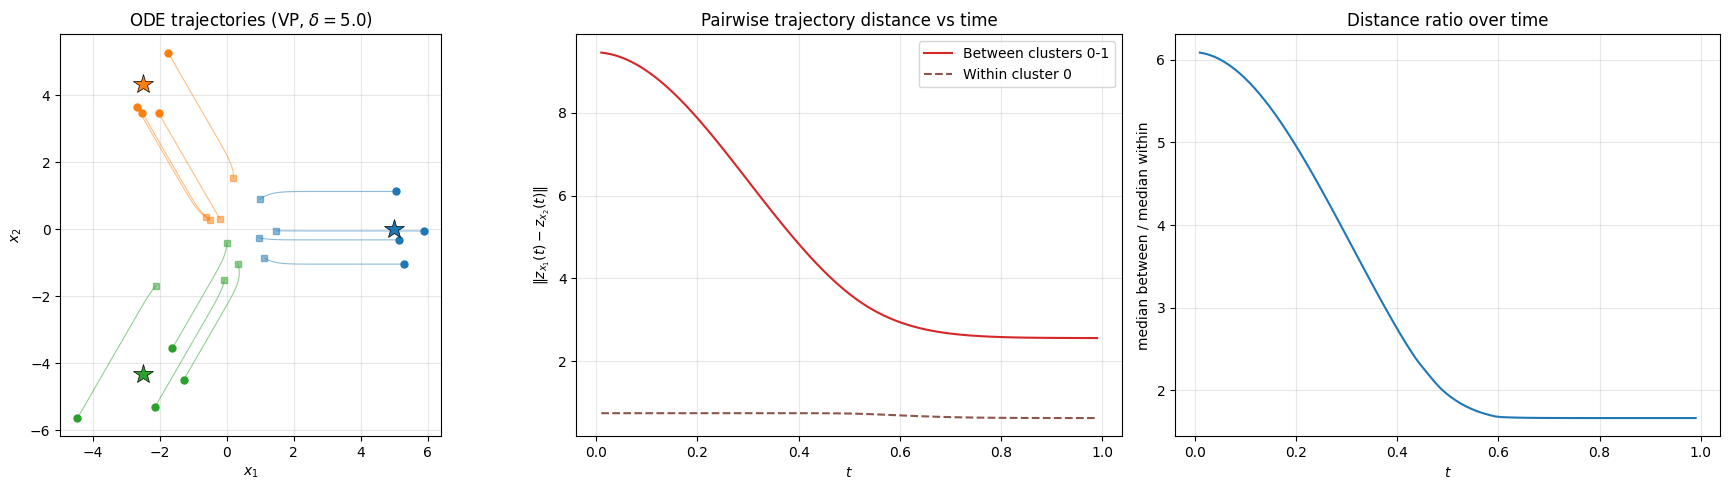

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['C0', 'C1', 'C2']

# Left: trajectories in data space
ax = axes[0]
for i in range(N_vis):
    k = labels_vis[i]
    ax.plot(traj_vis[i, :, 0], traj_vis[i, :, 1], '-', color=colors[k], alpha=0.5, lw=0.8)
    ax.plot(x_vis[i, 0], x_vis[i, 1], 'o', color=colors[k], ms=5)
    ax.plot(traj_vis[i, -1, 0], traj_vis[i, -1, 1], 's', color=colors[k], ms=4, alpha=0.5)
for k in range(K_vis):
    ax.plot(means_vis[k, 0], means_vis[k, 1], '*', color=colors[k], ms=15,
            markeredgecolor='black', markeredgewidth=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'ODE trajectories (VP, $\\delta={delta_vis}$)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# Middle: trajectory distance over time
ax = axes[1]
d_between = np.linalg.norm(traj_vis[0] - traj_vis[1], axis=1)
d_within = np.linalg.norm(traj_vis[0] - traj_vis[3], axis=1)
ax.plot(t_dense, d_between, '-', label='Between clusters 0-1', color='C3')
ax.plot(t_dense, d_within, '--', label='Within cluster 0', color='C5')
ax.set_xlabel('$t$'); ax.set_ylabel('$\\|z_{x_1}(t) - z_{x_2}(t)\\|$')
ax.set_title('Pairwise trajectory distance vs time')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: ratio over time
ax = axes[2]
ratio_t = []
for idx in range(len(t_dense)):
    z = traj_vis[:, idx, :]
    between, within = [], []
    for i in range(N_vis):
        for j in range(i+1, N_vis):
            d = np.linalg.norm(z[i] - z[j])
            if labels_vis[i] == labels_vis[j]:
                within.append(d)
            else:
                between.append(d)
    ratio_t.append(np.median(between) / np.median(within))
ax.plot(t_dense, ratio_t)
ax.set_xlabel('$t$'); ax.set_ylabel('median between / median within')
ax.set_title('Distance ratio over time')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 2. Varying Cluster Separation

Fix $K=3$ clusters, $N=30$ points (10 per cluster). Vary separation $\delta$ and measure $C(\text{mixture}) / C(\text{single cluster})$.

In [4]:
K_sep, D_sep = 3, 2
N_sep = 30
deltas = [0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]

ratios_sep = []
C_singles = []
C_mixtures = []

for delta in deltas:
    means_d = make_gmm_means(K_sep, D_sep, delta)
    covs_d = np.tile(np.eye(D_sep), (K_sep, 1, 1))
    w_d = np.ones(K_sep) / K_sep
    model_d = AnalyticScoreModel(means_d, covs_d, w_d, noise_schedule=ns)

    # Calibrate lambda from independent reference
    x_cal, _ = sample_gmm(means_d, covs_d, w_d, 200, seed=99)
    traj_cal = ode_trajectories(x_cal, model_d, t_eval)
    emb_cal = trajectory_embedding(traj_cal)
    lam = calibrate_bandwidth(emb_cal)

    # Single cluster
    rng = np.random.default_rng(SEED)
    x_single = rng.multivariate_normal(means_d[0], covs_d[0], N_sep)
    traj_s = ode_trajectories(x_single, model_d, t_eval)
    emb_s = trajectory_embedding(traj_s)
    res_s = compute_complexity(emb_s, lam)

    # Mixture (round-robin)
    x_mix, _ = sample_gmm_roundrobin(means_d, covs_d, N_sep, seed=SEED)
    traj_m = ode_trajectories(x_mix, model_d, t_eval)
    emb_m = trajectory_embedding(traj_m)
    res_m = compute_complexity(emb_m, lam)

    C_singles.append(res_s['C'])
    C_mixtures.append(res_m['C'])
    ratios_sep.append(res_m['C'] / res_s['C'])
    print(f'delta={delta:5.1f}: C_single={res_s["C"]:.3f}, C_mix={res_m["C"]:.3f}, ratio={ratios_sep[-1]:.3f}, lambda={lam:.6f}')

print('Done.')

delta=  0.5: C_single=8.652, C_mix=9.308, ratio=1.076, lambda=0.319979


delta=  1.0: C_single=7.994, C_mix=9.724, ratio=1.216, lambda=0.297053


delta=  2.0: C_single=6.916, C_mix=10.018, ratio=1.448, lambda=0.214547


delta=  3.0: C_single=6.273, C_mix=9.800, ratio=1.562, lambda=0.141152


delta=  5.0: C_single=5.175, C_mix=8.740, ratio=1.689, lambda=0.058345


delta=  8.0: C_single=4.334, C_mix=7.813, ratio=1.802, lambda=0.021829


delta= 12.0: C_single=3.894, C_mix=7.359, ratio=1.890, lambda=0.009270
Done.


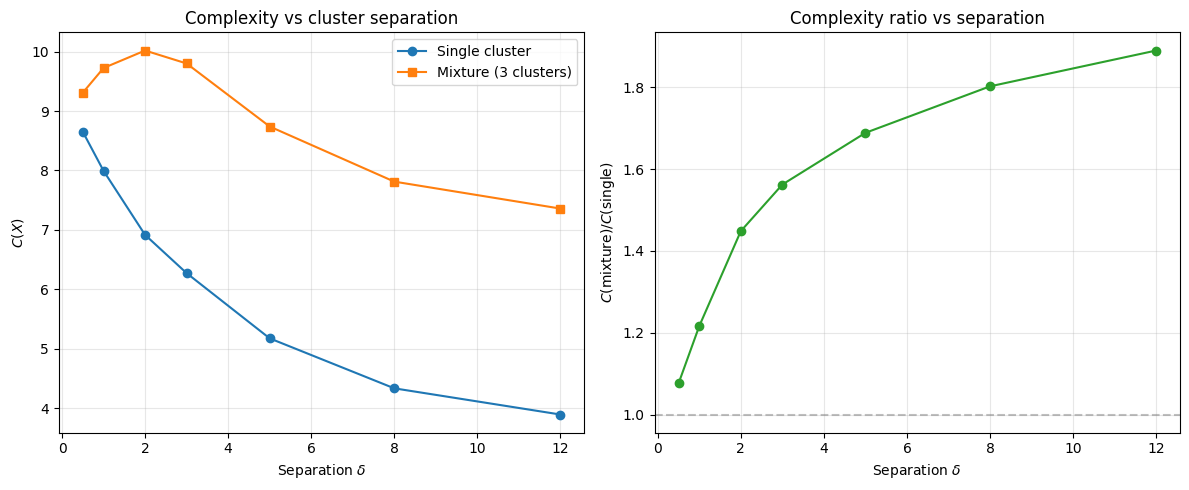

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(deltas, C_singles, 'o-', label='Single cluster')
ax.plot(deltas, C_mixtures, 's-', label=f'Mixture ({K_sep} clusters)')
ax.set_xlabel('Separation $\\delta$')
ax.set_ylabel('$C(X)$')
ax.set_title('Complexity vs cluster separation')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(deltas, ratios_sep, 'o-', color='C2')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Separation $\\delta$')
ax.set_ylabel('$C(\\mathrm{mixture}) / C(\\mathrm{single})$')
ax.set_title('Complexity ratio vs separation')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 3. Growth Rate: Linear vs Logarithmic

Compare two regimes as $N$ grows:
- **New cluster per point**: each point is the sole member of its own cluster. In the limit of well-separated clusters, $C \approx N \log 2$ (linear in $N$).
- **Single cluster**: all $N$ points from one Gaussian. $C \approx \log(1 + N)$ (logarithmic in $N$).

The model is built to know all clusters. For the new-cluster-per-point case, we place $N$ clusters on a circle with large separation.

In [6]:
D_gr = 5
delta_gr = 10.0
Ns_gr = [i+1 for i in range(10)]

C_linear = []
C_log = []

# For single-cluster: fix one model (3-component GMM) and always draw from cluster 0
K_single = 10
means_single = make_gmm_means(K_single, D_gr, 5.0)
covs_single = np.tile(np.eye(D_gr), (K_single, 1, 1))
w_single = np.ones(K_single) / K_single
model_single = AnalyticScoreModel(means_single, covs_single, w_single, noise_schedule=ns)

# Calibrate lambda for single-cluster model
x_cal_s, _ = sample_gmm(means_single, covs_single, w_single, 200, seed=99)
traj_cal_s = ode_trajectories(x_cal_s, model_single, t_eval)
emb_cal_s = trajectory_embedding(traj_cal_s)
lam_single = calibrate_bandwidth(emb_cal_s)
print(f'lambda (single-cluster model) = {lam_single:.6f}')

for N in Ns_gr:
    # --- New cluster per point ---
    means_n = make_gmm_means(N, D_gr, delta_gr)
    covs_n = np.tile(np.eye(D_gr), (N, 1, 1))
    w_n = np.ones(N) / N
    model_n = AnalyticScoreModel(means_n, covs_n, w_n, noise_schedule=ns)

    # Calibrate per N-cluster model
    x_cal_n, _ = sample_gmm(means_n, covs_n, w_n, 200, seed=99)
    traj_cal_n = ode_trajectories(x_cal_n, model_n, t_eval)
    emb_cal_n = trajectory_embedding(traj_cal_n)
    lam_n = calibrate_bandwidth(emb_cal_n)

    # One point per cluster
    rng_n = np.random.default_rng(SEED)
    x_nclust = np.array([rng_n.multivariate_normal(means_n[k], covs_n[k]) for k in range(N)])
    traj_nc = ode_trajectories(x_nclust, model_n, t_eval)
    emb_nc = trajectory_embedding(traj_nc)
    res_nc = compute_complexity(emb_nc, lam_n)
    C_linear.append(res_nc['C'])

    # --- Single cluster ---
    x_1clust = np.random.default_rng(SEED).multivariate_normal(
        means_single[0], covs_single[0], N)
    traj_1c = ode_trajectories(x_1clust, model_single, t_eval)
    emb_1c = trajectory_embedding(traj_1c)
    res_1c = compute_complexity(emb_1c, lam_single)
    C_log.append(res_1c['C'])

    print(f'N={N:3d}: C_new_cluster={res_nc["C"]:.3f}, C_single={res_1c["C"]:.3f}')

print('Done.')

lambda (single-cluster model) = 0.044383


N=  1: C_new_cluster=0.693, C_single=0.693


N=  2: C_new_cluster=1.386, C_single=1.221


N=  3: C_new_cluster=1.998, C_single=1.706


N=  4: C_new_cluster=2.591, C_single=2.045


...

N=  6: C_new_cluster=3.611, C_single=2.608


N=  7: C_new_cluster=4.054, C_single=3.054


N=  8: C_new_cluster=4.429, C_single=3.328


N=  9: C_new_cluster=4.749, C_single=3.496


N= 10: C_new_cluster=5.011, C_single=3.645
Done.


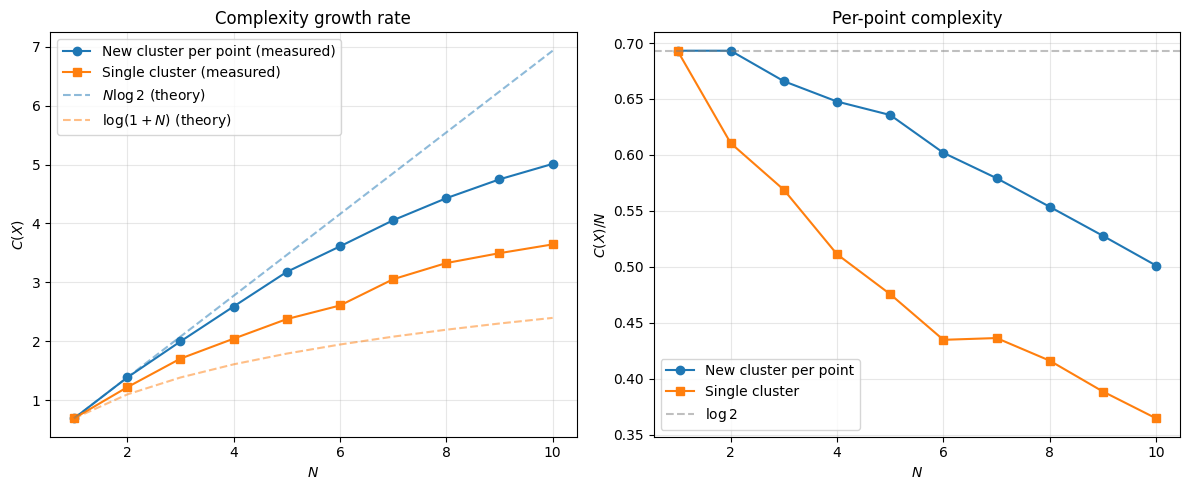

In [7]:
Ns_arr = np.array(Ns_gr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(Ns_arr, C_linear, 'o-', label='New cluster per point (measured)')
ax.plot(Ns_arr, C_log, 's-', label='Single cluster (measured)')
ax.plot(Ns_arr, Ns_arr * np.log(2), '--', color='C0', alpha=0.5, label='$N \\log 2$ (theory)')
ax.plot(Ns_arr, np.log(1 + Ns_arr), '--', color='C1', alpha=0.5, label='$\\log(1+N)$ (theory)')
ax.set_xlabel('$N$'); ax.set_ylabel('$C(X)$')
ax.set_title('Complexity growth rate')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(Ns_arr, np.array(C_linear) / Ns_arr, 'o-', label='New cluster per point')
ax.plot(Ns_arr, np.array(C_log) / Ns_arr, 's-', label='Single cluster')
ax.axhline(np.log(2), color='gray', ls='--', alpha=0.5, label='$\\log 2$')
ax.set_xlabel('$N$'); ax.set_ylabel('$C(X) / N$')
ax.set_title('Per-point complexity')
ax.legend(); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 4. Effect of Sample Variance

Fix the model (trained on a 3-component GMM with unit covariance). Then measure complexity of datasets drawn with different variances $\sigma^2_{\text{data}}$.

- Small variance: points tightly clustered, low within-cluster diversity
- Large variance: points spread out, clusters may overlap

The model is always the same — only the data distribution changes.

In [8]:
K_var, D_var = 3, 2
delta_var = 5.0
N_var = 30

means_var = make_gmm_means(K_var, D_var, delta_var)
covs_model = np.tile(np.eye(D_var), (K_var, 1, 1))
w_var = np.ones(K_var) / K_var
model_var = AnalyticScoreModel(means_var, covs_model, w_var, noise_schedule=ns)

# Calibrate lambda from the model's own distribution (unit variance)
x_cal_var, _ = sample_gmm(means_var, covs_model, w_var, 200, seed=99)
traj_cal_var = ode_trajectories(x_cal_var, model_var, t_eval)
emb_cal_var = trajectory_embedding(traj_cal_var)
lam_var = calibrate_bandwidth(emb_cal_var)
print(f'lambda (calibrated on unit-variance model) = {lam_var:.6f}')

sigmas_data = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
C_by_sigma_mix = []
C_by_sigma_single = []

for sig in sigmas_data:
    covs_data = sig**2 * np.tile(np.eye(D_var), (K_var, 1, 1))

    # Mixture from all clusters
    x_m, _ = sample_gmm_roundrobin(means_var, covs_data, N_var, seed=SEED)
    traj_m = ode_trajectories(x_m, model_var, t_eval)
    emb_m = trajectory_embedding(traj_m)
    res_m = compute_complexity(emb_m, lam_var)

    # Single cluster
    x_s = np.random.default_rng(SEED).multivariate_normal(
        means_var[0], covs_data[0], N_var)
    traj_s = ode_trajectories(x_s, model_var, t_eval)
    emb_s = trajectory_embedding(traj_s)
    res_s = compute_complexity(emb_s, lam_var)

    C_by_sigma_mix.append(res_m['C'])
    C_by_sigma_single.append(res_s['C'])
    print(f'sigma={sig:4.1f}: C_mix={res_m["C"]:.3f}, C_single={res_s["C"]:.3f}, ratio={res_m["C"]/res_s["C"]:.3f}')

print('Done.')

lambda (calibrated on unit-variance model) = 0.058345


sigma= 0.1: C_mix=7.049, C_single=3.466, ratio=2.034


sigma= 0.3: C_mix=7.239, C_single=3.696, ratio=1.958


sigma= 0.5: C_mix=7.580, C_single=4.072, ratio=1.862


sigma= 0.7: C_mix=8.017, C_single=4.507, ratio=1.779


sigma= 1.0: C_mix=8.740, C_single=5.175, ratio=1.689


sigma= 1.5: C_mix=9.899, C_single=6.249, ratio=1.584


sigma= 2.0: C_mix=10.882, C_single=7.245, ratio=1.502


sigma= 3.0: C_mix=12.288, C_single=9.120, ratio=1.347


sigma= 5.0: C_mix=13.827, C_single=12.184, ratio=1.135
Done.


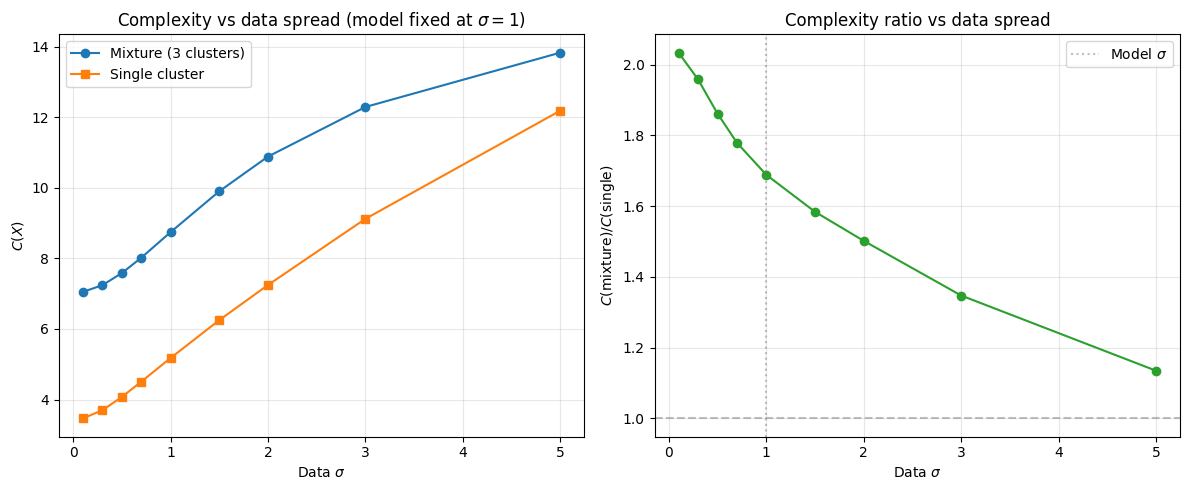

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(sigmas_data, C_by_sigma_mix, 'o-', label='Mixture (3 clusters)')
ax.plot(sigmas_data, C_by_sigma_single, 's-', label='Single cluster')
ax.set_xlabel('Data $\\sigma$')
ax.set_ylabel('$C(X)$')
ax.set_title('Complexity vs data spread (model fixed at $\\sigma=1$)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ratios_var = np.array(C_by_sigma_mix) / np.array(C_by_sigma_single)
ax.plot(sigmas_data, ratios_var, 'o-', color='C2')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.axvline(1.0, color='gray', ls=':', alpha=0.5, label='Model $\\sigma$')
ax.set_xlabel('Data $\\sigma$')
ax.set_ylabel('$C(\\mathrm{mixture}) / C(\\mathrm{single})$')
ax.set_title('Complexity ratio vs data spread')
ax.legend(); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()